In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


We want to find the $k$-dependent eigenvalues of matrix $\boldsymbol{A}_{\gamma}(k,\beta)$. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable and no clustering will occur.
The matrix depends on the pairwise interaction potential $W$ (rather, its Fourier transform).  
First, we define two functions. One computes matrix $\boldsymbol{A}_{\gamma}(k,\beta)$, the other one computes the spectral radii of $\boldsymbol{A}_{\gamma}(k,\beta)$ for a range of $\gamma$, $\beta$ and $k$ values.

In [21]:
# Matrix A for given Fourier coefficient \hat{W}(k) at fixed k, beta, gamma, L. 
# We truncate it after the first "dim" rows/columns.

def A_matrix(W_hat, k, beta, gamma, L, dim):
    
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex128)
    
    for i in range(dim-1):
        A_k[i][i] = i*(-gamma) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/beta)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/beta)*1j 
    
    A_k[dim-1][dim-1] = (dim-1)*(-gamma)
    
    A_k[1][0] += -k*np.sqrt(beta)*1j*W_hat(k)/L  
    
    return A_k




# For a given number of beta and gamma values, and wavenumbers up to k_max, this function yields 
# the spectral radius of A for each of them. It uses A_matrix from above.

def compute_spectral(W_hat, k_max, beta_list, gamma_list, L, dim ):

    N_beta = len(beta_list)
    N_gamma = len(gamma_list)
    
    spectral_radius = np.zeros((N_beta, N_gamma))  # Store spectral radius.
    
    print("Compute spectral radius...\n")
    
    for i in range(len(beta_list)):
        
        beta = beta_list[i]
        print(f"Testing beta {beta}.")
        
        for j in range(len(gamma_list)):
            
            gamma = gamma_list[j]
            
            # Get spectral radius for k=0.
            matrix = A_matrix(W_hat, 0, beta, gamma, L, dim)
            maximum = np.max( np.real( np.linalg.eigvals(matrix) ) ) 
            
            # Test all other wavenumbers.
            for z in range(1, k_max):
                
                k = 2*np.pi*z/L
                
                matrix = A_matrix(W_hat, k, beta, gamma, L, dim)
                
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
                
                
                # Test negative k.
                k = -k 
                matrix = A_matrix(W_hat, k, beta, gamma, L, dim)
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
            
            spectral_radius[i,j] = maximum
    
    return spectral_radius

<br>
Next, we define a plot function that will plot the results for the various potentials examined further below.


In [22]:
def plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, pot_name):
    
    suptitle_fs = 20
    
    plt.rcParams['axes.titlesize'] = 15     
    plt.rcParams['axes.labelsize'] = 15     
    plt.rcParams['axes.titlepad'] = 10
    


    fig = plt.figure(figsize=(18,5))

    ### Plot spectral radius against beta at fixed gamma, given by gamma_list[gamma_idx]. ###
    ax1 = fig.add_subplot(1,3,1)
    ax1.plot(beta_list, spectral_radius[:, gamma_idx])
    ax1.set_title(f'γ={gamma_list[gamma_idx]:.4f}', )
    ax1.set_xlabel('β')
    ax1.set_ylabel(r'$\psi_{\text{max}}$')

    ### Plot spectral radius vs. (gamma, beta). ###
    ax2 = fig.add_subplot(1,3,2, projection='3d')
    X, Y = np.meshgrid(gamma_list, beta_list)
    surf = ax2.plot_surface(X, Y, spectral_radius, cmap=plt.cm.cividis)
    ax2.set_xlabel('γ')
    ax2.set_ylabel('β')
    ax2.set_zlabel(r'$\psi_{\text{max}}$', labelpad=8)
    ax2.set_title(r'$\psi_{\text{max}}$ vs. $(\gamma, \beta)$' )
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, pad=0.12)

    ### Plot time to onset of clustering for fixed gamma at last tested beta. ###
    N_particle = 1000
    t_cl = np.log(N_particle)/(2*spectral_radius[-1, :])  ## See main text.
    
    ax3 = fig.add_subplot(1,3,3)
    ax3.plot(gamma_list, t_cl)
    ax3.set_title(r'$t_{\text{cl}}$ ' + f' for {N_particle} particles,  β={beta_list[-1]:.2f}', )
    ax3.set_xlabel('γ')
    ax3.set_ylabel(r"$t_{\mathrm{cl}}$", )
    
    fig.suptitle(pot_name, size=20, y=1.01)
    
    plt.tight_layout()
    plt.show()

<br>

## Gaussian Potential 

Since we are on the torus, we may use the periodic extension of the Gaussian interaction potential, which will ease the calculation.  
The potential is given by 
$$W(r) = -\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by

$$
\begin{align}
\hat{W}(k) &= \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr, \\
           &=- \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr, \\
           &= -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr,\\
           &= -\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr, \\
           &= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.
\end{align}
$$


An alternative is to use the non-periodic Gaussian (the one actually considered in the simulation):

$$ 
\hat{W}(k)=-\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right).
$$

Here, $erf$ denotes the error function. Since $\frac{\sigma}{L}$ is small, the differences between the two expressions are exponentially small.

In [23]:
# Fourier transform of the Gaussian interaction.

sigma = np.sqrt(0.5)    # Width.
L = 10                  # Boxlength.

# Wrapped / periodic Gaussian.
def W_hat_gauss(k):
    W_hat_k = -np.sqrt(2*np.pi)*sigma*np.exp(-sigma**2 * k**2 /2) 
    return W_hat_k

# Non-wrapped case:
# from scipy.special import erf
# def W_hat_gauss(k):
#    W_hat_k = -np.sqrt(2*np.pi)*sigma * np.exp(-sigma**2 *k**2 /2)*np.real( erf( (0.5*L + 1j*k*sigma**2)/(np.sqrt(2*sigma**2)) ) )
#    return W_hat_k


In [24]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 200
beta_list = np.linspace(5, 7, N_beta)      # Make sure grid has the correct range 
                                           # and is fine enough to pinpoint beta_c.

N_gamma = 5                                # beta_c should be independent of gamma,
gamma_list = np.linspace(0.1, 5, N_gamma)  # but it makes sense to test a few to verify this.


dim = 50    # Pick large enough such that results converge.

k_max = 50  # Pick large enough such that results converge.

spectral_radius = compute_spectral(W_hat_gauss, k_max, beta_list, gamma_list, L, dim)

Compute spectral radius...

Testing beta 5.0.
Testing beta 5.010050251256281.
Testing beta 5.0201005025125625.
Testing beta 5.030150753768845.
Testing beta 5.040201005025126.
Testing beta 5.050251256281407.
Testing beta 5.060301507537688.
Testing beta 5.0703517587939695.
Testing beta 5.080402010050252.
Testing beta 5.090452261306533.
Testing beta 5.100502512562814.
Testing beta 5.110552763819095.
Testing beta 5.1206030150753765.
Testing beta 5.130653266331659.
Testing beta 5.14070351758794.
Testing beta 5.150753768844221.
Testing beta 5.160804020100502.
Testing beta 5.1708542713567835.
Testing beta 5.180904522613066.
Testing beta 5.190954773869347.
Testing beta 5.201005025125628.
Testing beta 5.211055276381909.
Testing beta 5.221105527638191.
Testing beta 5.231155778894473.
Testing beta 5.241206030150754.
Testing beta 5.251256281407035.
Testing beta 5.261306532663316.
Testing beta 5.271356783919598.
Testing beta 5.28140703517588.
Testing beta 5.291457286432161.
Testing beta 5.301507537

In [25]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )


Linear stability analysis result for critical Beta:  6.236180904522613




Formula for critical beta $\beta_c$ for the Gaussian interaction by Martzel & Aslangul (2001):

$ \beta_c = \frac{L^d}{(2\pi)^{\frac{d}{2}}\sigma^d}$  

for dimensionality $d$ ($d=1$ in our case). 

In [26]:
# Print critical beta given by literature (Martzel & Aslangul, 2001).

print('Theoretical critcal beta in 1D ', L/(sigma*np.sqrt(2*np.pi)))
print('Theoretical critcal beta in 2D ', L**2/(sigma**2*2*np.pi)) 
print('Theoretical critcal beta in 3D ', L**3/(sigma**3*(2*np.pi)**(3/2)))


Theoretical critcal beta in 1D  5.6418958354775635
Theoretical critcal beta in 2D  31.83098861837906
Theoretical critcal beta in 3D  179.58712212516653


The deviations between the literature result (in 1D) and our result decrease for smaller $\frac{\sigma}{L}$ as can be easily verified be re-running the script for different values of $L$ and $\sigma$. See also Fig. 10 in the article.

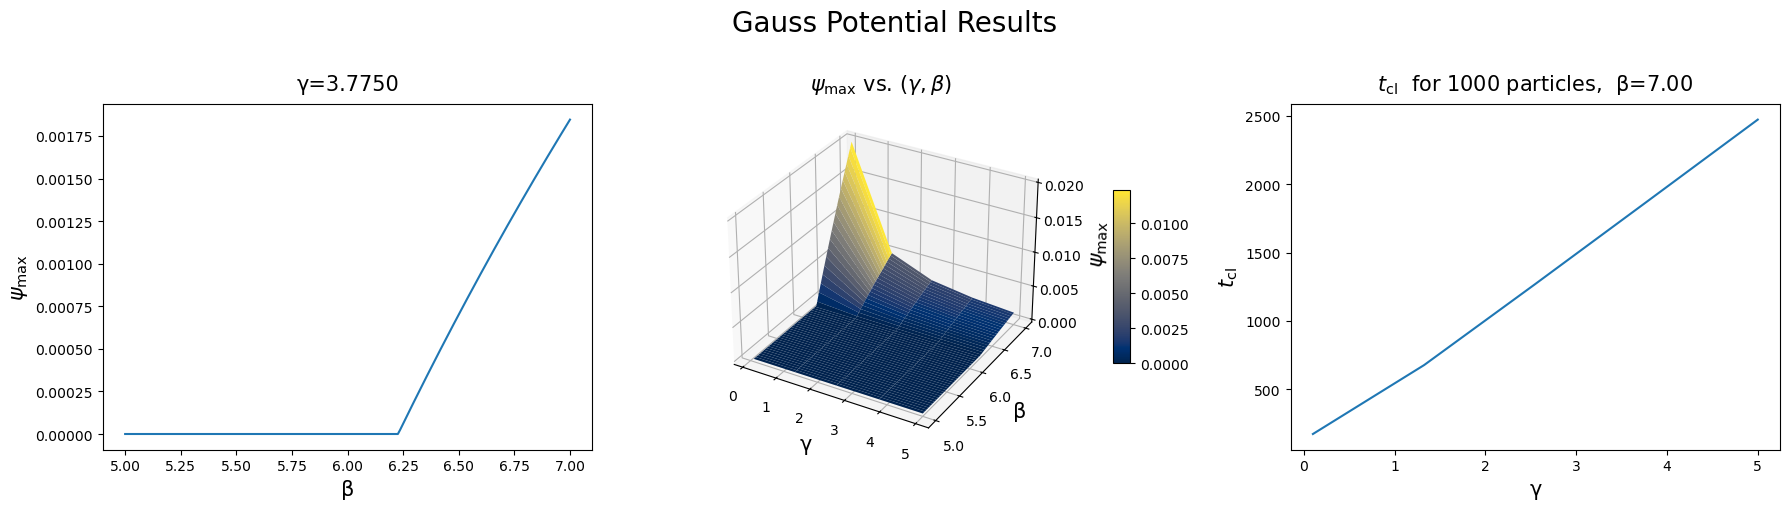

In [28]:
plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "Gauss Potential Results")


As can be seen from the second plot, $\beta_c$ is independent of friction $\gamma$ as expected.

From the final plot, we observe an overall linear regime of $t_{\text{cl}}$ with an upward bending for $\gamma \to 0$ (which is somewhat consistent with the simulation results in the main text).

<br>

## Morse potential

The Morse potential is given by $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)}).$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by
$$\hat{W}(k) =  \int^{L/2}_{-L/2} W(r)\cos{(kr)}dr. $$
In contrast to the Gaussian case, we have to resort to numerical quadrature to evaluate $\hat{W}(k)$.

In [29]:
from scipy.integrate import quad

L  = 10
De = 1
re = 0
a  = 2

def integrand_morse(r, k):
    res = De * ( np.exp(-2*a*(np.abs(r)-re)) - 2*np.exp(-a*(np.abs(r)-re)) ) * np.cos(k*r)
    return res 

def W_hat_morse(k):
    W_hat_k = quad(integrand_morse, -L/2, L/2, args=(k))
    return W_hat_k[0]

In [30]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 200
beta_list = np.linspace(6, 8, N_beta)     

N_gamma = 5                            
gamma_list = np.linspace(0.1, 5, N_gamma)

dim = 50    

k_max = 50  

spectral_radius = compute_spectral(W_hat_morse, k_max, beta_list, gamma_list, L, dim)

Compute spectral radius...

Testing beta 6.0.
Testing beta 6.010050251256281.
Testing beta 6.0201005025125625.
Testing beta 6.030150753768845.
Testing beta 6.040201005025126.
Testing beta 6.050251256281407.
Testing beta 6.060301507537688.
Testing beta 6.0703517587939695.
Testing beta 6.080402010050252.
Testing beta 6.090452261306533.
Testing beta 6.100502512562814.
Testing beta 6.110552763819095.
Testing beta 6.1206030150753765.
Testing beta 6.130653266331659.
Testing beta 6.14070351758794.
Testing beta 6.150753768844221.
Testing beta 6.160804020100502.
Testing beta 6.1708542713567835.
Testing beta 6.180904522613066.
Testing beta 6.190954773869347.
Testing beta 6.201005025125628.
Testing beta 6.211055276381909.
Testing beta 6.221105527638191.
Testing beta 6.231155778894473.
Testing beta 6.241206030150754.
Testing beta 6.251256281407035.
Testing beta 6.261306532663316.
Testing beta 6.271356783919598.
Testing beta 6.28140703517588.
Testing beta 6.291457286432161.
Testing beta 6.301507537

In [31]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 1 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )

Linear stability analysis result for critical Beta:  7.507537688442211


## GEM-$\alpha$

The GEM-$\alpha$ potential is given by 
$$W(r) = -e^{-\Big(\frac{\|r\|}{\sqrt{2\sigma^2}}\Big)^\alpha}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by
$$\hat{W}(k) =  \int^{L/2}_{-L/2} W(r)\cos{(kr)}dr, $$
and we use numerical quadrature again to evaluate it.

In [32]:
from scipy.integrate import quad

L  = 10
sigma = np.sqrt(0.5)
alpha  = 4.0

def integrand_GEM(r, k):
    res = -np.exp( -( np.abs(r)/np.sqrt(2*(sigma**2)) )**alpha ) * np.cos(k*r)
    return res 


def W_hat_GEM(k):
    W_hat_k = quad(integrand_GEM, -L/2, L/2, args = (k,))
    return W_hat_k[0]


In [33]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 200
beta_list = np.linspace(5, 7, N_beta)     

N_gamma = 5                            
gamma_list = np.linspace(0.1, 5, N_gamma)

dim = 50    

k_max = 50  

spectral_radius = compute_spectral(W_hat_GEM, k_max, beta_list, gamma_list, L, dim)

Compute spectral radius...

Testing beta 5.0.
Testing beta 5.010050251256281.
Testing beta 5.0201005025125625.
Testing beta 5.030150753768845.
Testing beta 5.040201005025126.
Testing beta 5.050251256281407.
Testing beta 5.060301507537688.
Testing beta 5.0703517587939695.
Testing beta 5.080402010050252.
Testing beta 5.090452261306533.
Testing beta 5.100502512562814.
Testing beta 5.110552763819095.
Testing beta 5.1206030150753765.
Testing beta 5.130653266331659.
Testing beta 5.14070351758794.
Testing beta 5.150753768844221.
Testing beta 5.160804020100502.
Testing beta 5.1708542713567835.
Testing beta 5.180904522613066.
Testing beta 5.190954773869347.
Testing beta 5.201005025125628.
Testing beta 5.211055276381909.
Testing beta 5.221105527638191.
Testing beta 5.231155778894473.
Testing beta 5.241206030150754.
Testing beta 5.251256281407035.
Testing beta 5.261306532663316.
Testing beta 5.271356783919598.
Testing beta 5.28140703517588.
Testing beta 5.291457286432161.
Testing beta 5.301507537

In [34]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )

Linear stability analysis result for critical Beta:  5.9045226130653266


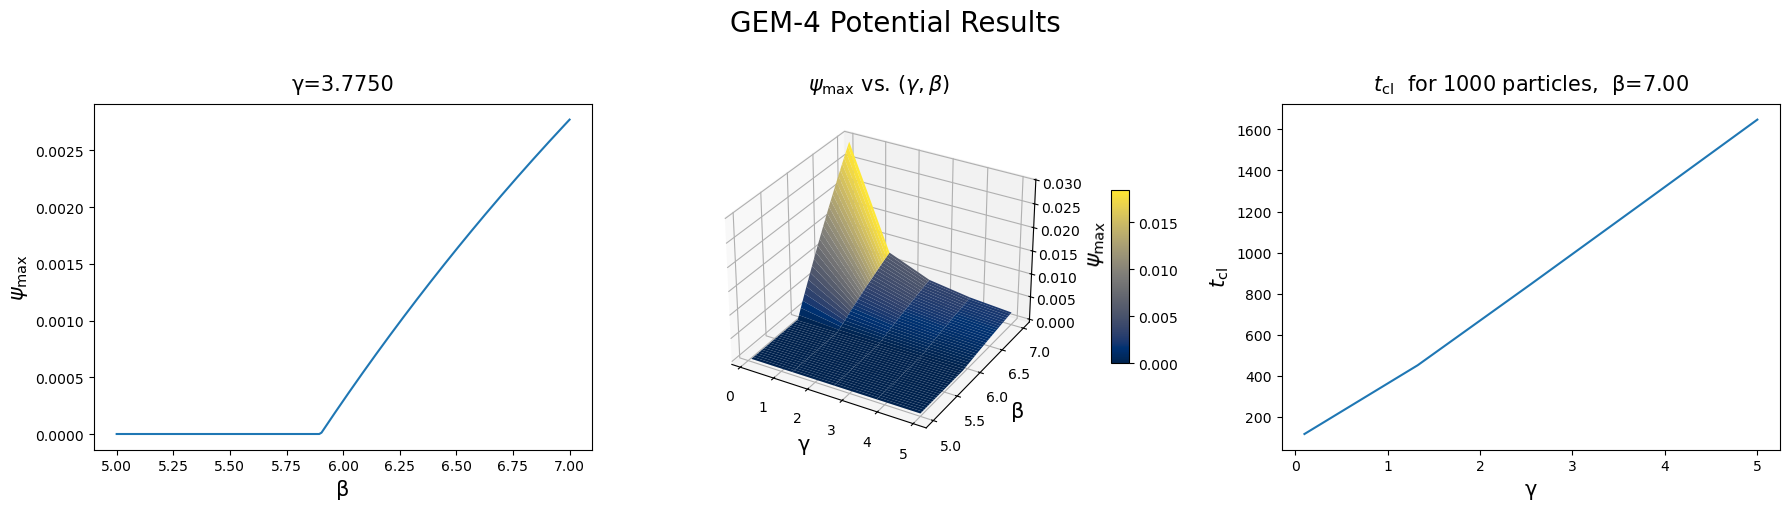

In [35]:

plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "GEM-4 Potential Results")

# Fluctuation Analysis
We want to compute the spatial correlation of the spatial marginal fluctuation 
$\tilde{\mu}(t,x) := \int \mu(t,x,v)dv$, i.e.,
$\mathbb{E}(\tilde{\mu}(t,x)\overline{\tilde{\mu}(t,x')})$ at different times $t$.

Since $\tilde{\hat{\mu}}(t,k)=c_0(t,k)$, we compute 
$\mathbb{E}|c_0(t,k)|^2$ for the Fourier modes 
$k=\pm \frac{2\pi n}{L}$ and recover the spatial signal via inverse Fourier analysis. First, we define functions to compute $\mathbb{E}|c_0(t,k)|^2$ on a list of wavenumbers.


In [38]:
from scipy.linalg import expm
from scipy.integrate import quad

"""
Integrand in formula for E( |c_0(k,t)|^2 ).
"""
def integrand(s, t, A):
        
    exp_A = expm((t-s)*A)  # Matrix exponential.
    
    n, m = exp_A.shape
    D = np.diag(np.arange(0, m))  # This is B B^T after the correction B_jj = sqrt(j).
    
    # We only need the (0,0)-entry, because the spatial marginal is c_0.
    integrand_matrix = exp_A @ D @ exp_A.conj().T
    
    return np.real(integrand_matrix[0, 0])
    


"""
Obtain E( |c_0(k,t)|^2 ).
"""
def get_fourier_coefficient(k, t, L, dim, beta, gamma, W_hat):
    
    # The k=0 mass mode is conserved and removed from the fluctuation sum.
    if np.isclose(k, 0.0):
        return 0.0
    
    # Obtain matrix A.
    A = A_matrix(W_hat, k, beta, gamma, L, dim)
    
    # Compute the two terms of the covariance.
    exp_A_t = expm(t * A)
    Term1 = (exp_A_t @ exp_A_t.conj().T)[0, 0]

    integral = quad(integrand, 0, t, args=(t, A), limit=200)[0]
    Term2 = 2*gamma*integral
    
    mean_c0_sq = np.real(Term1 + Term2)  # E( |c_0(k,t)|^2 ).
    
    return mean_c0_sq




"""
For a given list of wavenumbers k, obtain Fourier coefficients E( |c_0(k,t)|^2 ).
"""
def get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat):
    
    out = []
    
    for k in k_list:
        mean_c0_sq = get_fourier_coefficient(k, t, L, dim, beta, gamma, W_hat)
        out += [mean_c0_sq]
    
    return np.array(out)


Next we define a plotting function that takes the Fourier coefficients $\mathbb{E}|c_0(t,k)|^2$ obtained from the functions above and plots the inverse Fourier transform against $x-x'$ at time $t$.


In [37]:
def plot_fluctuation_real_space(f_hat, t, filename=None):
    
    N = len(f_hat)
    
    # Inverse FFT to get f(x) in physical space.
    f_x = np.fft.ifft(np.fft.ifftshift(f_hat))
    f_x = np.fft.fftshift(f_x)
    f_x *= N
    f_x /= L**2

    x = np.linspace(-L/2, L/2, N, endpoint=False)

    # Estimate amplitude of fluctuation by cropping Dirac out.
    AMPL = np.max(np.real(f_x[:int(0.45*np.size(f_x))]))
    ylims = [-2*AMPL, 2*AMPL]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.set_ylim(ylims)
    ax.plot(x, np.real(f_x), label="Real part")
    ax.plot(x, np.imag(f_x), '--', label="Imaginary part")
    ax.set_title("$t$ = "+str(t), fontsize=20)
    ax.set_xlabel("$x-x'$", fontsize=20)
    ax.set_ylabel(r'$\mathbb{E}(\tilde{\mu}(t,x)\overline{\tilde{\mu}(t,x^\prime)})$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=14, width=1.2, length=4)
    ax.legend(fontsize=16, loc='upper left')
    ax.grid(True)
    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")

    plt.show()
    


<br>
We now consider the Gaussian interaction potential as an example again and plot $\mathbb{E}(\tilde{\mu}(t,x)\overline{\tilde{\mu}(t,x')})$ for different times $t$ at some $\beta > \beta_c$.


In [39]:
# Parameters.
N = 512       # Number of Fourier modes to consider.
dim = 25      # Number of rows/cols of matrix A to consider.
gamma = 1.0
beta = 25
W_hat = W_hat_gauss  # Fourier transform of Gauss interaction (see previous section).


k_list = 2 * np.pi * np.fft.fftfreq(N, d=L / N) # List of wavenumbers to consider.



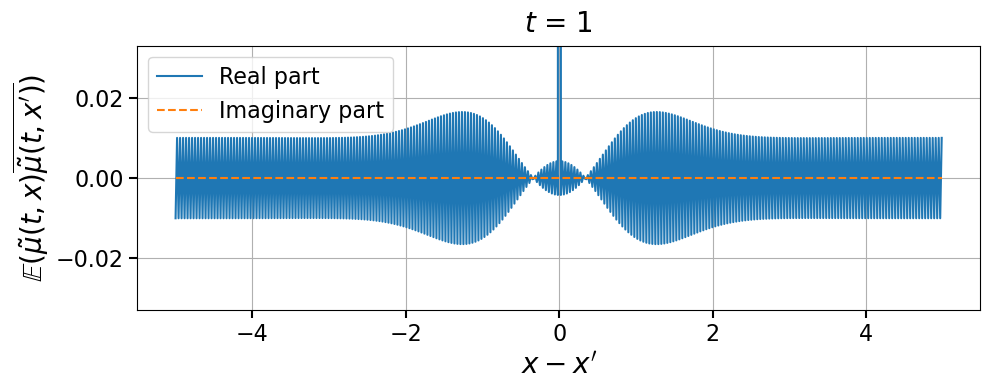

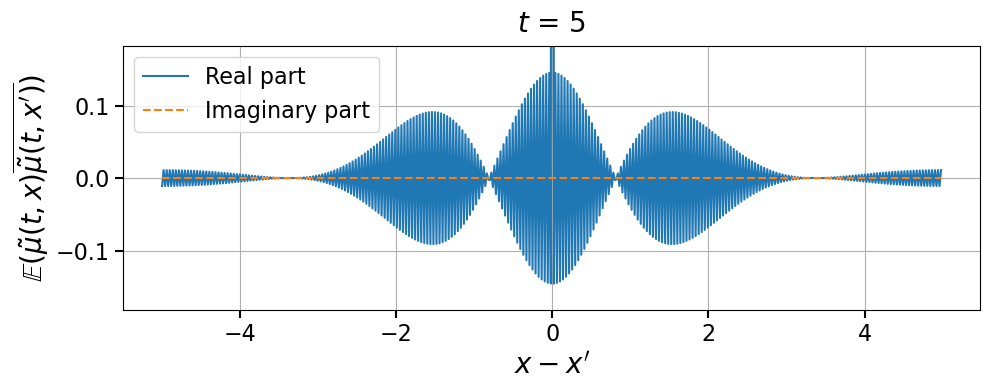

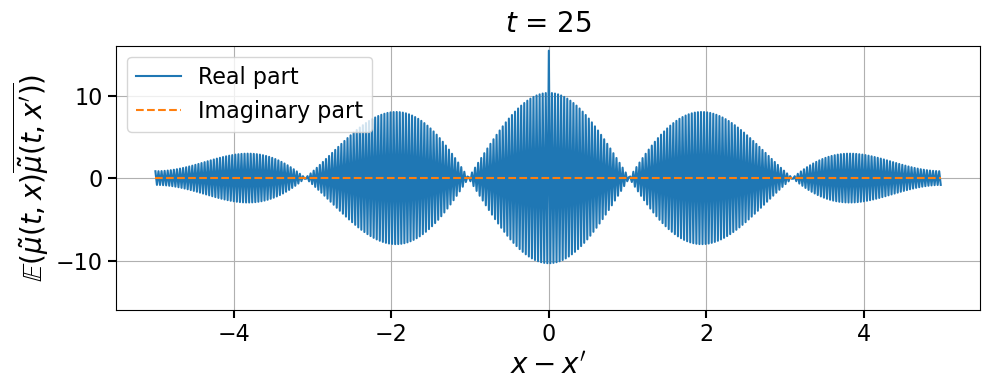

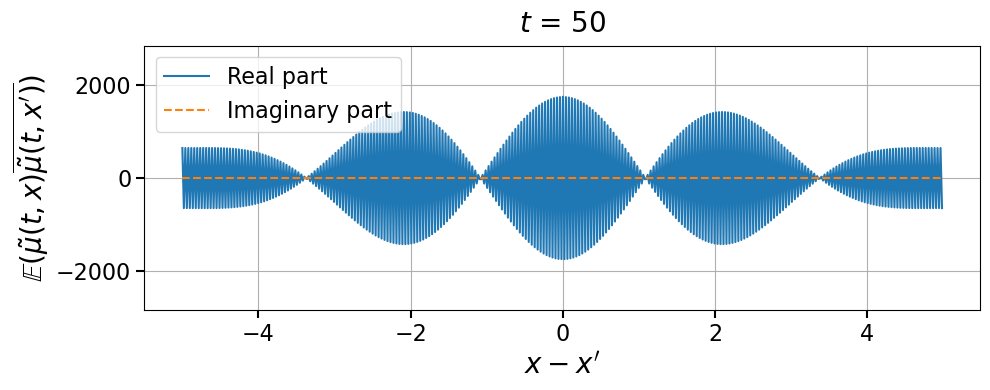

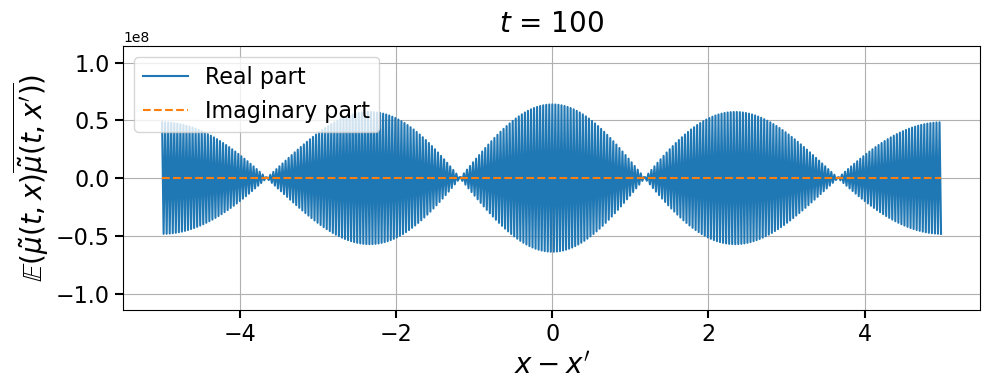

In [40]:
# Plot and save spatial fluctuations over time.
for t in [1, 5, 25, 50, 100]:

    f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)
    plot_fluctuation_real_space(
        f_hat,
        t,
        filename=f"Fluctuate_T={t}.pdf"
    )


We observe that the amplitude of the spatial autocorrelation of $\tilde{\mu}$ becomes cosine-modulated and exponentially larger with progressing time.
<br>
Next, we examine the growth of the amplitude with time $t$. For that aim, we first define a function that collects these amplitudes at a list of time values.


In [41]:
def AMP_lists(k_list, t_list, L, dim, beta, gamma, W_hat):  
    
    print("Computing fluctuation amplitudes at different times...\n")
    
    AMP_list = []
    
    for t in t_list:
    
        print(f"t={t}\n")
        f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  
            
        f_x = np.fft.ifft(np.fft.ifftshift(f_hat))  # Shift to match fftfreq order.
        f_x = f_x * N
        f_x = f_x / L**2
        f_x = np.fft.fftshift(f_x)


        # Amplitude := Maximum of first 45% of values (see text below).
        AMPL = np.max(np.real(f_x[:int(0.45*np.size(f_x))]))
        AMP_list.append(AMPL)
        
    return AMP_list
    


Since for small times $t$ there is no well defined amplitude as the Dirac-Peak is still decaying, we heuristically estimate "the amplitude" to be the maximum value of $\mathbb{E}(\tilde{\mu}(t,x)\overline{\tilde{\mu}(t,x')})$ outside of a small region around $x-x'=0$, which crops out the Dirac part.

<br>
Next, we run this function for three different friction values $\gamma$ and plot the results together with the curve $e^{2\psi_{\text{max}}t}$, with $\psi_{\text{max}}$ the spectral radius of matrix $A$.


In [42]:

beta = 25

eps = 0.1
t_list = np.linspace(eps, 100, 20)

gammas = [1.0, 0.1, 0.01] 
amp_list = []
expo_psi_max_list = []

for gamma in gammas:
    print(f"\nGamma = {gamma}.")

    amp_list += [AMP_lists(k_list, t_list, L, dim, beta, gamma, W_hat)]

    # Spectral radius of A at given gamma, beta (see first half of notebook).
    psi_max = compute_spectral(W_hat_gauss, int(len(k_list)/2), [beta], [gamma], L, dim )[0][0]
    expo_psi_max_list += [np.exp(2*psi_max*t_list)]



Gamma = 1.0.
Computing fluctuation amplitudes at different times...

t=0.1

t=5.3578947368421055

t=10.615789473684211

t=15.873684210526317

t=21.131578947368425

t=26.38947368421053

t=31.647368421052636

t=36.905263157894744

t=42.16315789473685

t=47.42105263157895

t=52.678947368421056

t=57.93684210526317

t=63.19473684210527

t=68.45263157894738

t=73.71052631578948

t=78.96842105263158

t=84.22631578947369

t=89.48421052631579

t=94.7421052631579

t=100.0

Compute spectral radius...

Testing beta 25.

Gamma = 0.1.
Computing fluctuation amplitudes at different times...

t=0.1

t=5.3578947368421055

t=10.615789473684211

t=15.873684210526317

t=21.131578947368425

t=26.38947368421053

t=31.647368421052636

t=36.905263157894744

t=42.16315789473685

t=47.42105263157895

t=52.678947368421056

t=57.93684210526317

t=63.19473684210527

t=68.45263157894738

t=73.71052631578948

t=78.96842105263158

t=84.22631578947369

t=89.48421052631579

t=94.7421052631579

t=100.0

Compute spectra

/tmp/ipykernel_120252/2655077317.py:37: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(integrand, 0, t, args=(t, A), limit=200)[0]


t=26.38947368421053

t=31.647368421052636

t=36.905263157894744

t=42.16315789473685

t=47.42105263157895

t=52.678947368421056

t=57.93684210526317

t=63.19473684210527

t=68.45263157894738

t=73.71052631578948

t=78.96842105263158

t=84.22631578947369

t=89.48421052631579

t=94.7421052631579

t=100.0

Compute spectral radius...

Testing beta 25.


<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_120252/2848589751.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title('$β =$'+str(beta)+', $\gamma =$'+str(gamma), fontsize=20)


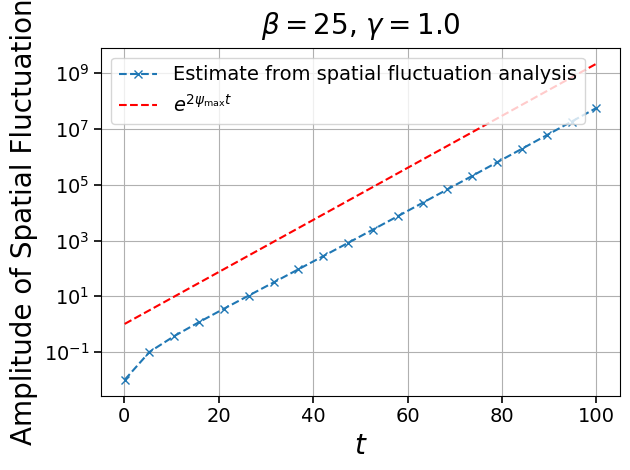

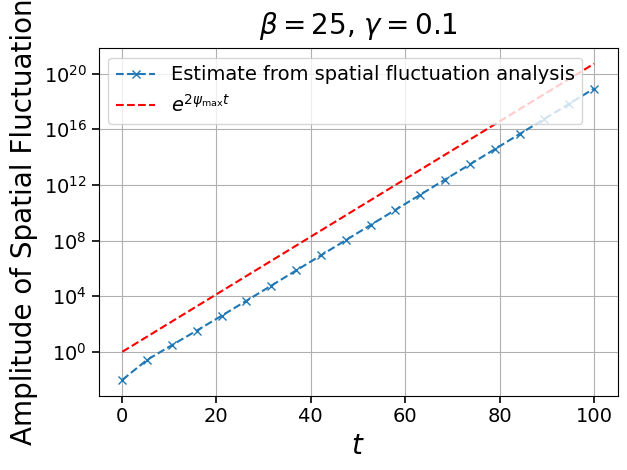

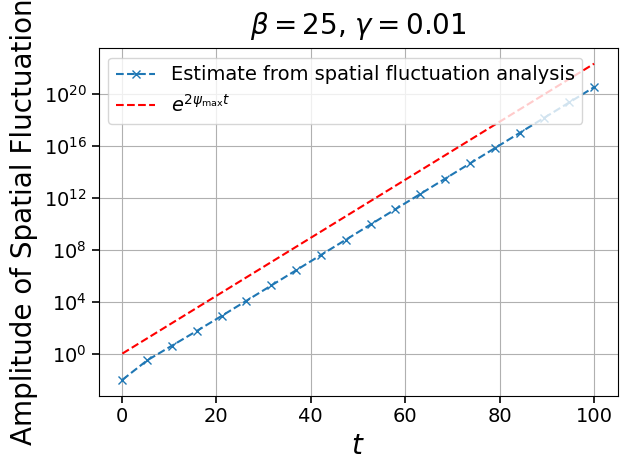

In [43]:
# Plot results.

for (gamma, amp, expo_psi_max) in zip(gammas, amp_list, expo_psi_max_list):
    
    fig, ax = plt.subplots()

    # Plot original data.
    ax.semilogy(t_list, amp, 'x--', label='Estimate from spatial fluctuation analysis')

    # Plot best-fit line.
    ax.semilogy(t_list, expo_psi_max, 'r--', label=fr'$e^{{2 \psi_{{\max}} t}}$')

    
    ax.grid()
    ax.legend(fontsize=14, loc='upper left')
    ax.set_xlabel('$t$', fontsize=20)
    ax.set_ylabel('Amplitude of Spatial Fluctuation', fontsize=20)
    ax.set_title('$β =$'+str(beta)+', $\gamma =$'+str(gamma), fontsize=20)

    # Tick label size and tick mark size.
    ax.tick_params(axis='both', which='major', labelsize=14, width=1.2, length=5)
    ax.tick_params(axis='both', which='minor', labelsize=12, width=1.0, length=3)

    fig.tight_layout()
    fig.savefig(f"Fluctuate_gam={gamma}.pdf", bbox_inches="tight")
    plt.show()

The plots show that the spatial fluctuation amplitudes obtained from the linear stability analysis qualitatively align with $e^{2\psi_{\text{max}}t}$, which can then be used to derive an expression for the time to the onset of clustering (see main text).


# Effect of Matrix Truncation and Finite Number of Wavenumbers
Since the matrix $\boldsymbol{A}_{\gamma}(k,\beta)$ is infinite-dimensional and would need to be evaluated at an infinite number of $k$-values, we should test that the results obtained from truncating it after $m$ rows and with only using $n$ wavenumbers converge rapidly enough with increasing $m$ and $n$.

We start by changing the number of matrix rows considered, keeping $n$ fix and large, and obtaining the spectral radius for each case. Using a large number of considered matrix rows yields an estimate of the ground truth. We then plot the errors of the spectral radius against number of considered matrix rows.


In [44]:
gamma = [1.0]  # Some values. 
beta = [25]    # The results were observed to be reasonably independent of them. 

W_hat = W_hat_gauss   # Specify interaction potential. 

approxim_dim_list = range(2,30) # Numbers of rows to consider.

errors_list = []

k_max = 30    # Large values that lead to converged results.
m_max = 100

ground_truth = compute_spectral(W_hat, k_max, beta, gamma, L, m_max )[0][0]  


# Obtain errors for all numbers of considered matrix rows.
for i in approxim_dim_list:
    print(f"Using {i} matrix rows.")
    errors_list.append(np.abs(compute_spectral(W_hat, k_max, beta, gamma, L, i)[0][0] - ground_truth))




Compute spectral radius...

Testing beta 25.
Using 2 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 3 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 4 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 5 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 6 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 7 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 8 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 9 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 10 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 11 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 12 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 13 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 14 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 15 matrix rows.
Compute spectral radius...

Testing beta 25.
Using 16 matrix rows.
Com

In [50]:
approxim_dim_list

range(2, 30)

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_120252/2196056986.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi_{\max} - \hat{\psi}_{\max}|$', fontsize = '22')


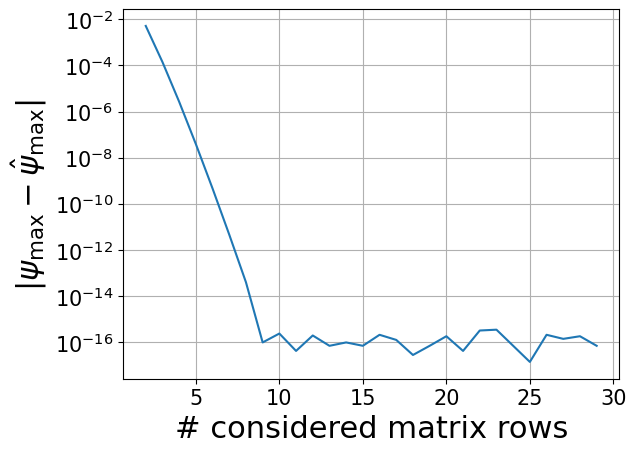

In [53]:
# Plot results.
plt.plot(np.array(approxim_dim_list), errors_list)
plt.yscale('log')
plt.xlabel('# considered matrix rows', fontsize = '22')
plt.ylabel('$|\psi_{\max} - \hat{\psi}_{\max}|$', fontsize = '22')
plt.xticks(fontsize = '15')
plt.yticks(fontsize = '15')
plt.grid()
plt.show()


We see that the results have already converged at 10 matrix rows, implying that the 30 rows we used for our experiments were more than sufficient.

Next, we fix the number of matrix rows and repeat the same experiment for varying numbers of considered wavenumbers.

In [54]:
gamma = [1.0]  # Some values. 
beta = [25]    # The results were observed to be reasonably independent of them. 

W_hat = W_hat_gauss   # Specify interaction potential.

k_range = range(1,31) # Numbers of k-values to consider (their negative counterparts will also be used)

errors_list = []

m_max = 30

# Obtain errors for all numbers of considered matrix rows.
for i in k_range:
    print(f"Using {i} wavenumbers.")
    errors_list.append(np.abs(compute_spectral(W_hat, i, beta, gamma, L, m_max)[0][0] - ground_truth))


Using 1 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 2 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 3 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 4 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 5 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 6 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 7 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 8 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 9 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 10 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 11 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 12 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 13 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 14 wavenumbers.
Compute spectral radius...

Testing beta 25.
Using 15 wavenumbers.
Compute spectral radius...

Testing beta 25.
Usin

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_120252/1959652586.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi_{\max} - \hat{\psi}_{\max}|$', fontsize = '22')


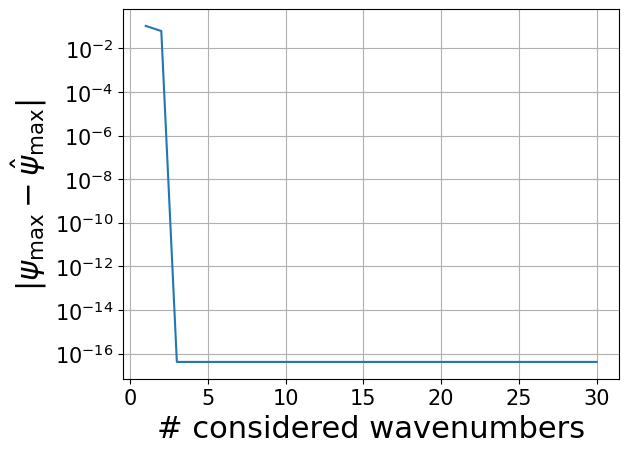

In [55]:
# Plot results.
plt.plot(k_range,errors_list)
plt.xlabel('# considered wavenumbers', fontsize = '22')
plt.ylabel('$|\psi_{\max} - \hat{\psi}_{\max}|$', fontsize = '22')
plt.yscale("log")
plt.xticks(fontsize = '15')
plt.yticks(fontsize = '15')
plt.grid()
plt.show()


Even more so than for the different number of rows, the results converge rapidly with the number of considered wavenumbers. Only 4 to 5 (excluding their negative images) are truly relevant.